# Урок 1. Свой autograd за 100 строк

🎯 **Цели урока**

- написать класс `Value`, который запоминает вычисления и умеет считать градиенты;
- сверить наши градиенты с PyTorch;
- собрать из `Value` нейрон, слой и MLP и обучить сеть классифицировать точки;
- понять, почему в настоящих библиотеках работают с тензорами, а не с отдельными числами.

📖 **Теория:** раздел «Обратное распространение и autograd».

Идея урока — micrograd Андрея Карпатого (см. «Что почитать» в теории); код написан заново.

In [1]:
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_moons

## 1. Класс Value

`Value` хранит число, градиент и «рецепт»: из каких значений оно получено (`parents`) и как раздать
свой градиент родителям (`_backward`). Каждая операция создаёт новый `Value` и запоминает свой
кусочек цепного правила.

In [2]:
class Value:
    def __init__(self, data: float, parents: tuple["Value", ...] = (), op: str = ""):
        self.data = float(data)
        self.grad = 0.0
        self.parents = parents
        self.op = op
        self._backward = lambda: None  # по умолчанию — лист графа, раздавать некому

    def __repr__(self) -> str:
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    @staticmethod
    def wrap(x) -> "Value":
        return x if isinstance(x, Value) else Value(x)

    def __add__(self, other):
        other = Value.wrap(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():                 # d(a+b)/da = 1, d(a+b)/db = 1
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = Value.wrap(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():                 # d(ab)/da = b, d(ab)/db = a
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self, k: float):
        out = Value(self.data**k, (self,), f"**{k}")

        def _backward():
            self.grad += k * self.data ** (k - 1) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad  # (e^x)' = e^x

        out._backward = _backward
        return out

    def log(self):
        out = Value(math.log(self.data), (self,), "log")

        def _backward():
            self.grad += out.grad / self.data

        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), "relu")

        def _backward():
            self.grad += (self.data > 0) * out.grad

        out._backward = _backward
        return out

    # остальные операции выражаются через уже написанные
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-Value.wrap(other))

    def __truediv__(self, other):
        return self * Value.wrap(other) ** -1

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def __rsub__(self, other):
        return Value.wrap(other) - self

    def __rtruediv__(self, other):
        return Value.wrap(other) / self

    def backward(self):
        """Обратный проход: градиенты всех значений, от которых зависит self."""
        order, seen = [], set()

        def visit(v):  # топологическая сортировка: родители раньше детей
            if id(v) not in seen:
                seen.add(id(v))
                for p in v.parents:
                    visit(p)
                order.append(v)

        visit(self)
        self.grad = 1.0  # dL/dL = 1
        for v in reversed(order):
            v._backward()

Ключевая строка в каждом `_backward` — `+=`. Если значение используется дважды, градиенты по обоим
путям складываются. Проверим на $y = x \cdot x$: производная $2x$ получается только при накоплении.

In [3]:
x = Value(3.0)
y = x * x
y.backward()
print(y, "  dy/dx =", x.grad)

Value(data=9.0000, grad=1.0000)   dy/dx = 6.0


## 2. Сверка с PyTorch

Возьмём выражение посложнее — со всеми операциями — и посчитаем градиенты двумя способами.

In [4]:
def expression(a, b, c, tanh, exp, log):
    d = a * b + c**2
    e = tanh(d) * exp(a / 4) - log(c) / b
    return (e + 1) ** 3 - a * e


a, b, c = Value(0.7), Value(-1.3), Value(2.1)
out = expression(a, b, c, Value.tanh, Value.exp, Value.log)
out.backward()

ta, tb, tc = (torch.tensor(v, dtype=torch.float64, requires_grad=True) for v in (0.7, -1.3, 2.1))
t_out = expression(ta, tb, tc, torch.tanh, torch.exp, torch.log)
t_out.backward()

print(f"значение: {out.data:.10f}  vs  PyTorch {t_out.item():.10f}")
for name, ours, theirs in [("a", a, ta), ("b", b, tb), ("c", c, tc)]:
    print(f"d/d{name}: {ours.grad:.10f}  vs  {theirs.grad.item():.10f}")

значение: 19.7880722005  vs  PyTorch 19.7880722005
d/da: 4.6996549903  vs  4.6996549903
d/db: 9.7912059362  vs  9.7912059362
d/dc: 8.5168239379  vs  8.5168239379


Совпадение до последнего знака. `loss.backward()` в PyTorch делает то же самое, только для тензоров
и с сотнями реализованных операций.

## 3. Нейрон, слой, MLP

In [5]:
random.seed(0)


class Neuron:
    def __init__(self, n_in: int, nonlinear: bool = True):
        scale = (2 / n_in) ** 0.5  # инициализация Kaiming для ReLU
        self.w = [Value(random.gauss(0, scale)) for _ in range(n_in)]
        self.b = Value(0.0)
        self.nonlinear = nonlinear

    def __call__(self, x):
        z = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return z.relu() if self.nonlinear else z

    def parameters(self):
        return [*self.w, self.b]


class Layer:
    def __init__(self, n_in: int, n_out: int, **kwargs):
        self.neurons = [Neuron(n_in, **kwargs) for _ in range(n_out)]

    def __call__(self, x):
        return [n(x) for n in self.neurons]

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]


class MLP:
    def __init__(self, sizes: list[int]):
        self.layers = [Layer(sizes[i], sizes[i + 1], nonlinear=i < len(sizes) - 2) for i in range(len(sizes) - 1)]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0] if len(x) == 1 else x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


model = MLP([2, 16, 16, 1])
print("параметров:", len(model.parameters()))

параметров: 337


## 4. Обучение на «полумесяцах»

Два класса точек в форме переплетённых полумесяцев — линейно не разделимы. Модель выдаёт логит,
потери — бинарная кросс-энтропия в устойчивой форме: $\log(1 + e^{-y z})$ для меток $y = \pm 1$.

In [6]:
X, y = make_moons(n_samples=100, noise=0.1, random_state=0)
y_pm = 2 * y - 1  # метки −1 и +1


def loss_and_accuracy():
    logits = [model([Value(x1), Value(x2)]) for x1, x2 in X]
    losses = [(1 + (-yi * z).exp()).log() for yi, z in zip(y_pm, logits)]
    l2 = sum(p * p for p in model.parameters())
    loss = sum(losses) / len(losses) + 1e-4 * l2
    accuracy = np.mean([(z.data > 0) == (yi > 0) for yi, z in zip(y_pm, logits)])
    return loss, accuracy


history = []
velocity = {id(p): 0.0 for p in model.parameters()}
start = time.perf_counter()
for step in range(100):
    loss, acc = loss_and_accuracy()
    for p in model.parameters():
        p.grad = 0.0            # обнулить градиенты — как optimizer.zero_grad()
    loss.backward()
    for p in model.parameters():  # SGD с momentum из M01: v ← 0,9·v + g, θ ← θ − η·v
        velocity[id(p)] = 0.9 * velocity[id(p)] + p.grad
        p.data -= 0.1 * velocity[id(p)]
    history.append((loss.data, acc))
    if step % 20 == 0 or step == 99:
        print(f"шаг {step:2}: loss = {loss.data:.4f}, accuracy = {acc:.2f}")
print(f"время: {time.perf_counter() - start:.1f} с")

шаг  0: loss = 1.0725, accuracy = 0.29


шаг 20: loss = 0.2381, accuracy = 0.89


шаг 40: loss = 0.1860, accuracy = 0.91


шаг 60: loss = 0.1464, accuracy = 0.98


шаг 80: loss = 0.1078, accuracy = 0.98


шаг 99: loss = 0.0722, accuracy = 0.99
время: 64.1 с


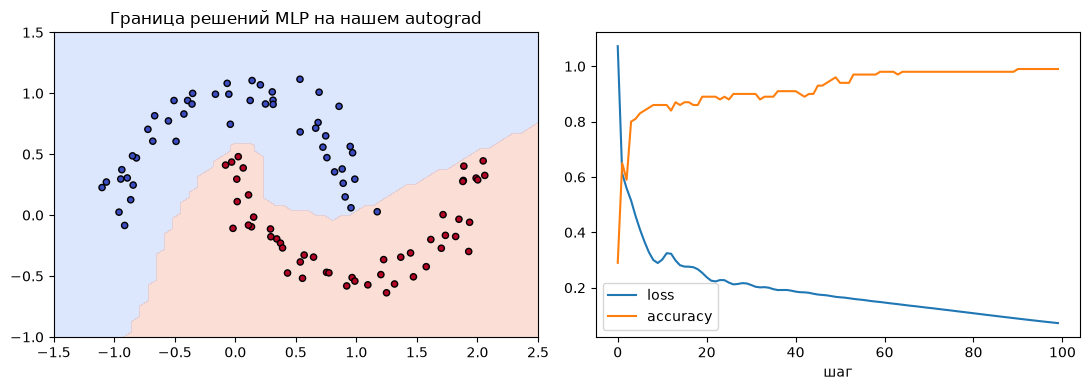

In [7]:
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 60), np.linspace(-1, 1.5, 60))
zz = np.array([model([Value(a), Value(b)]).data for a, b in zip(xx.ravel(), yy.ravel())]).reshape(xx.shape)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.contourf(xx, yy, zz > 0, alpha=0.3, cmap="coolwarm")
a1.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=20, edgecolor="k")
a1.set_title("Граница решений MLP на нашем autograd")
a2.plot([h[0] for h in history], label="loss")
a2.plot([h[1] for h in history], label="accuracy")
a2.set_xlabel("шаг")
a2.legend()
plt.tight_layout()
plt.show()

## 5. Почему не так в настоящих библиотеках

Каждое число — отдельный объект Python, каждая операция — вызов функции. Посчитаем, сколько
вершин в графе одного шага обучения, и сравним время с тем же MLP на тензорах PyTorch.

In [8]:
def count_nodes(root):
    seen, stack = set(), [root]
    while stack:
        v = stack.pop()
        if id(v) not in seen:
            seen.add(id(v))
            stack.extend(v.parents)
    return len(seen)


loss, _ = loss_and_accuracy()
print(f"вершин в графе одного шага: {count_nodes(loss):,}".replace(",", " "))

torch_mlp = torch.nn.Sequential(torch.nn.Linear(2, 16), torch.nn.ReLU(), torch.nn.Linear(16, 16),
                                torch.nn.ReLU(), torch.nn.Linear(16, 1))
Xt, yt = torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
opt = torch.optim.SGD(torch_mlp.parameters(), lr=0.1, momentum=0.9)

t0 = time.perf_counter()
for _ in range(100):
    opt.zero_grad()
    loss_t = torch.nn.functional.binary_cross_entropy_with_logits(torch_mlp(Xt).squeeze(1), yt)
    loss_t.backward()
    opt.step()
torch_time = time.perf_counter() - t0
acc_t = ((torch_mlp(Xt).squeeze(1) > 0) == (yt > 0)).float().mean().item()
print(f"PyTorch: 100 шагов за {torch_time * 1000:.0f} мс, accuracy = {acc_t:.2f}")

вершин в графе одного шага: 65 919


PyTorch: 100 шагов за 23 мс, accuracy = 0.99


Наш граф на один шаг — десятки тысяч объектов, и работает он в тысячи раз медленнее. PyTorch строит граф
из **тензорных** операций: одно матричное умножение вместо тысяч умножений чисел, и выполняется оно
оптимизированным кодом на CPU или GPU. Идея при этом та же: запомнить операции, пройти граф назад,
накопить градиенты.

## ✅ Итоги

- Autograd = граф операций + локальные производные + обход в обратном топологическом порядке.
- Градиенты **накапливаются**, поэтому их обнуляют перед каждым шагом.
- Нейрон, слой, MLP и цикл обучения — несколько десятков строк поверх autograd.
- Библиотеки работают с тензорами, потому что граф из отдельных чисел слишком медленный.

✍️ **Упражнение:** `exercises/ex01_autograd.py` — операции и обратный проход для своего `Value`.